In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import zipfile

zip_path = '/content/drive/MyDrive/garbage_dataset/garbage-classification.zip'

extract_path = '/content/garbage_dataset'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)


In [ ]:
import os
os.listdir(extract_path)


['garbage-dataset']

In [ ]:
import os

data_path = '/content/garbage_dataset/garbage-dataset'
print("Subfolders (classes) in dataset:")
print(os.listdir(data_path))


Subfolders (classes) in dataset:
['cardboard', 'trash', 'battery', 'biological', 'shoes', 'glass', 'plastic', 'paper', 'metal', 'clothes']


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.applications import MobileNetV3Large
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
import os
import numpy as np
from sklearn.utils.class_weight import compute_class_weight


# Image parameters
IMG_SIZE = 224
BATCH_SIZE = 32
DATA_DIR = '/content/garbage_dataset/garbage-dataset'  # Your validated path

# ✅ Data Augmentation + Validation Split
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=25,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2]
)

# ✅ Class Imbalance Handling (class_weight will be computed later)
train_generator = datagen.flow_from_directory(
    DATA_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_generator = datagen.flow_from_directory(
    DATA_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=True
)

# ✅ Base Model with Transfer Learning
base_model = MobileNetV3Large(
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    weights='imagenet'
)

# Freeze the early layers
for layer in base_model.layers[:30]:
    layer.trainable = False

# ✅ Custom Classifier + Dropout (Regularization)
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(train_generator.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

# ✅ Compile the Model
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ✅ Regularization + Model Deployment Ready: EarlyStopping & Checkpoint
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
checkpoint = ModelCheckpoint("/content/drive/MyDrive/best_model.keras", save_best_only=True)

# Optional: Compute class weights (for class imbalance)
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

labels = train_generator.classes
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(labels), y=labels)
class_weights = dict(enumerate(class_weights))

# ✅ Train the Model with everything integrated
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=30,
    callbacks=[early_stop, checkpoint],
    class_weight=class_weights  # Helps handle class imbalance
)

# ✅ Evaluate after training
loss, acc = model.evaluate(val_generator)
print(f"✅ Final Validation Accuracy: {acc:.2%}")

# ✅ Save final model to Google Drive (very important!)
model.save("/content/drive/MyDrive/garbage_classifier_final.keras")


Found 15813 images belonging to 10 classes.
Found 3949 images belonging to 10 classes.


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
495/495 ━━━━━━━━━━━━━━━━━━━━ 375s 656ms/step - accuracy: 0.3823 - loss: 1.7676 - val_accuracy: 0.0524 - val_loss: 2.6705
Epoch 2/30
495/495 ━━━━━━━━━━━━━━━━━━━━ 317s 642ms/step - accuracy: 0.7414 - loss: 0.7915 - val_accuracy: 0.1185 - val_loss: 2.4844
Epoch 3/30
495/495 ━━━━━━━━━━━━━━━━━━━━ 293s 593ms/step - accuracy: 0.8186 - loss: 0.5748 - val_accuracy: 0.1611 - val_loss: 2.6267
Epoch 4/30
495/495 ━━━━━━━━━━━━━━━━━━━━ 317s 641ms/step - accuracy: 0.8520 - loss: 0.4443 - val_accuracy: 0.2365 - val_loss: 2.5272
Epoch 5/30
495/495 ━━━━━━━━━━━━━━━━━━━━ 319s 644ms/step - accuracy: 0.8793 - loss: 0.3722 - val_accuracy: 0.3049 - val_loss: 2.2870
Epoch 6/30
495/495 ━━━━━━━━━━━━━━━━━━━━ 295s 590ms/step - accuracy: 0.8996 - loss: 0.3002 - val_accuracy: 0.3636 - val_loss: 2.4165
Epoch 7/30
495/495 ━━━━━━━━━━━━━━━━━━━━ 323s 654ms/step - accuracy: 0.9156 - loss: 0.2606 - val_accuracy: 0.4052 - val_loss: 2.0230
Epoch 8/30
495/495 ━━━━━━━━━━━━━━━━━━━━ 295s 596ms/step - accuracy: 0.9206 -

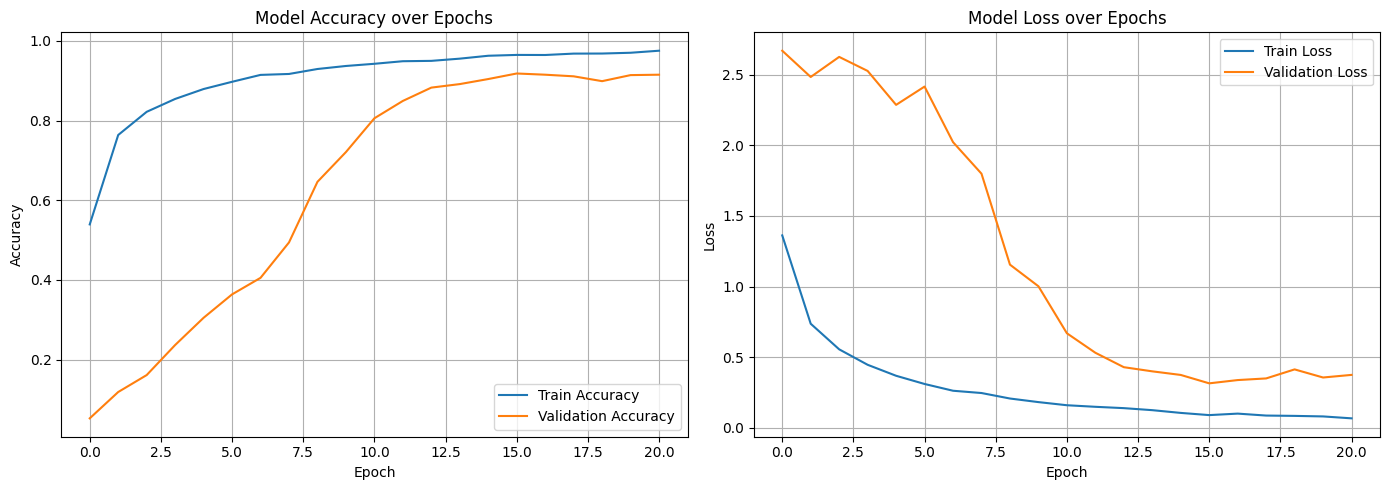

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(14, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [ ]:
from tensorflow.keras.models import load_model

# Load the saved model from Drive
model = load_model('/content/drive/MyDrive/garbage_classifier_final.keras')


In [ ]:
# ✅ Import libraries
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.models import load_model
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import os


In [ ]:
# ✅ Define paths and parameters
IMG_SIZE = 224
BATCH_SIZE = 32
DATA_DIR = '/content/garbage_dataset/garbage-dataset'
MODEL_PATH = '/content/drive/MyDrive/garbage_classifier_final.keras'
CHECKPOINT_PATH = '/content/drive/MyDrive/best_model.keras'


In [ ]:
# ✅ Recreate generators
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=25,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2]
)

train_generator = datagen.flow_from_directory(
    DATA_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_generator = datagen.flow_from_directory(
    DATA_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=True
)


NameError: name 'DATA_DIR' is not defined

In [ ]:
# ✅ Compute class weights
labels = train_generator.classes
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(labels), y=labels)
class_weights = dict(enumerate(class_weights))


In [ ]:
from tensorflow.keras.models import load_model

# Load the saved model from Drive
model = load_model('/content/drive/MyDrive/garbage_classifier_final.keras')


In [ ]:
# ✅ Re-define callbacks with increased patience if needed
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
checkpoint = ModelCheckpoint(CHECKPOINT_PATH, save_best_only=True)


In [ ]:
# ✅ Resume training from epoch 22 to 30
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=30,
    initial_epoch=21,  # resumes from epoch 22
    callbacks=[early_stop, checkpoint],
    class_weight=class_weights
)


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 22/30
495/495 ━━━━━━━━━━━━━━━━━━━━ 410s 729ms/step - accuracy: 0.9679 - loss: 0.0935 - val_accuracy: 0.9086 - val_loss: 0.3788
Epoch 23/30
495/495 ━━━━━━━━━━━━━━━━━━━━ 321s 648ms/step - accuracy: 0.9668 - loss: 0.0907 - val_accuracy: 0.9109 - val_loss: 0.3669
Epoch 24/30
495/495 ━━━━━━━━━━━━━━━━━━━━ 316s 635ms/step - accuracy: 0.9729 - loss: 0.0855 - val_accuracy: 0.9223 - val_loss: 0.3604
Epoch 25/30
495/495 ━━━━━━━━━━━━━━━━━━━━ 316s 638ms/step - accuracy: 0.9748 - loss: 0.0732 - val_accuracy: 0.9104 - val_loss: 0.3978
Epoch 26/30
495/495 ━━━━━━━━━━━━━━━━━━━━ 314s 635ms/step - accuracy: 0.9724 - loss: 0.0745 - val_accuracy: 0.9099 - val_loss: 0.4044
Epoch 27/30
495/495 ━━━━━━━━━━━━━━━━━━━━ 314s 636ms/step - accuracy: 0.9709 - loss: 0.0860 - val_accuracy: 0.8987 - val_loss: 0.4541
Epoch 28/30
495/495 ━━━━━━━━━━━━━━━━━━━━ 309s 624ms/step - accuracy: 0.9724 - loss: 0.0684 - val_accuracy: 0.9169 - val_loss: 0.3645
Epoch 29/30
495/495 ━━━━━━━━━━━━━━━━━━━━ 309s 624ms/step - accuracy: 

In [ ]:
model.save('/content/drive/MyDrive/my_model.keras')


In [ ]:
from tensorflow.keras.models import load_model

model = load_model('/content/drive/MyDrive/my_model.keras')


/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 148 variables whereas the saved optimizer has 294 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = 224
BATCH_SIZE = 32
DATA_DIR = '/content/garbage_dataset/garbage-dataset'

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=25,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2]
)

train_generator = datagen.flow_from_directory(
    DATA_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_generator = datagen.flow_from_directory(
    DATA_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=True
)


Found 15813 images belonging to 10 classes.
Found 3949 images belonging to 10 classes.


In [ ]:
loss, acc = model.evaluate(train_generator)
print(f"✅ Final Training Accuracy: {acc:.2%}")

val_loss, val_acc = model.evaluate(val_generator)
print(f"✅ Final Validation Accuracy: {val_acc:.2%}")



495/495 ━━━━━━━━━━━━━━━━━━━━ 243s 491ms/step - accuracy: 0.9838 - loss: 0.0482
✅ Final Training Accuracy: 98.35%
124/124 ━━━━━━━━━━━━━━━━━━━━ 61s 488ms/step - accuracy: 0.9246 - loss: 0.3518
✅ Final Validation Accuracy: 92.45%


In [ ]:
# ✅ For training (with augmentation)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=25,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2]
)

# ✅ For validation (NO augmentation, only rescaling)
val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)


In [ ]:
train_generator = train_datagen.flow_from_directory(
    DATA_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True  # Training should be shuffled
)

val_generator = val_datagen.flow_from_directory(
    DATA_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False  # ❗ Do not shuffle validation set
)


Found 15813 images belonging to 10 classes.
Found 3949 images belonging to 10 classes.


In [ ]:
loss, acc = model.evaluate(train_generator)
print(f"✅ Final Training Accuracy: {acc:.2%}")

val_loss, val_acc = model.evaluate(val_generator)
print(f"✅ Final Validation Accuracy: {val_acc:.2%}")


495/495 ━━━━━━━━━━━━━━━━━━━━ 241s 487ms/step - accuracy: 0.9833 - loss: 0.0537
✅ Final Training Accuracy: 98.37%
124/124 ━━━━━━━━━━━━━━━━━━━━ 12s 99ms/step - accuracy: 0.9444 - loss: 0.2264
✅ Final Validation Accuracy: 93.06%


In [ ]:
from google.colab import files
uploaded = files.upload()


Saving images.jpg to images.jpg


1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


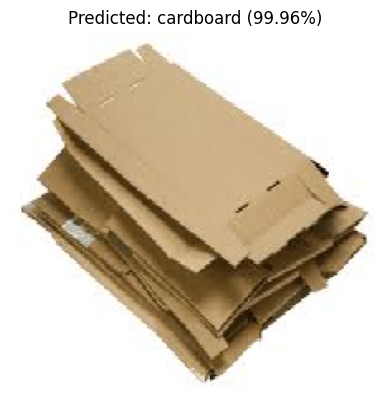

In [ ]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

# ✅ Load your saved model from Drive
model = load_model('/content/drive/MyDrive/my_model.keras')


# ✅ Define class labels (same order as used during training)
class_labels = ['battery', 'biological', 'cardboard', 'clothes', 'glass',
                'metal', 'paper', 'plastic', 'shoes', 'trash']

# ✅ Use the uploaded image path
img_path = 'images.jpg'


# ✅ Load and preprocess the image
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

# ✅ Predict the class
prediction = model.predict(img_array)
predicted_index = np.argmax(prediction)
predicted_class = class_labels[predicted_index]
confidence = np.max(prediction)

# ✅ Show result
plt.imshow(img)
plt.axis('off')
plt.title(f"Predicted: {predicted_class} ({confidence:.2%})")
plt.show()


In [ ]:
print("grads shape:", grads.shape)

grads shape: (1, 960)


In [ ]:
for i, layer in enumerate(model.layers):
    print(i, layer.name, layer.output.shape)


0 input_layer (None, 224, 224, 3)
1 rescaling (None, 224, 224, 3)
2 conv (None, 112, 112, 16)
3 conv_bn (None, 112, 112, 16)
4 activation (None, 112, 112, 16)
5 expanded_conv_depthwise (None, 112, 112, 16)
6 expanded_conv_depthwise_bn (None, 112, 112, 16)
7 re_lu (None, 112, 112, 16)
8 expanded_conv_project (None, 112, 112, 16)
9 expanded_conv_project_bn (None, 112, 112, 16)
10 expanded_conv_add (None, 112, 112, 16)
11 expanded_conv_1_expand (None, 112, 112, 64)
12 expanded_conv_1_expand_bn (None, 112, 112, 64)
13 re_lu_1 (None, 112, 112, 64)
14 expanded_conv_1_depthwise_pad (None, 113, 113, 64)
15 expanded_conv_1_depthwise (None, 56, 56, 64)
16 expanded_conv_1_depthwise_bn (None, 56, 56, 64)
17 re_lu_2 (None, 56, 56, 64)
18 expanded_conv_1_project (None, 56, 56, 24)
19 expanded_conv_1_project_bn (None, 56, 56, 24)
20 expanded_conv_2_expand (None, 56, 56, 72)
21 expanded_conv_2_expand_bn (None, 56, 56, 72)
22 re_lu_3 (None, 56, 56, 72)
23 expanded_conv_2_depthwise (None, 56, 56, 72)
24

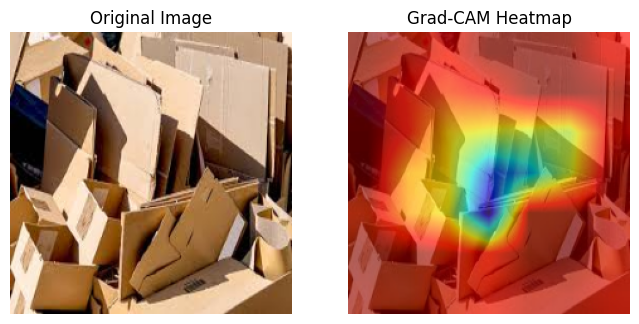

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Model

# ✅ Load image
img_path = 'download (3).jpg'  # Make sure the image exists
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

# ✅ Create model for Grad-CAM
grad_model = Model(
    inputs=model.inputs,
    outputs=[model.get_layer("activation_19").output, model.output]
)

with tf.GradientTape() as tape:
    conv_outputs, predictions = grad_model(img_array)
    pred_index = tf.argmax(predictions[0])
    loss = predictions[:, pred_index]

# ✅ Get gradients and pooled grads
grads = tape.gradient(loss, conv_outputs)
pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
conv_outputs = conv_outputs[0]

# ✅ Weight feature maps
heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
heatmap = tf.squeeze(heatmap)
heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)

# ✅ Display
import cv2
import matplotlib.cm as cm

# Load original image
img_original = cv2.imread(img_path)
img_original = cv2.resize(img_original, (224, 224))
heatmap = cv2.resize(heatmap.numpy(), (224, 224))

# Color map overlay
heatmap = np.uint8(255 * heatmap)
colormap = cm.jet(heatmap)[:, :, :3]
superimposed_img = np.uint8(0.6 * colormap * 255 + 0.4 * img_original)

# Show
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(cv2.cvtColor(img_original, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Grad-CAM Heatmap")
plt.imshow(cv2.cvtColor(superimposed_img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()
